# Sprint 2 Exploratory Analysis: RADAR vs LiDAR

## Goal
Explore measurable patterns in TruckScenes that may help identify conditions where 4D RADAR provides useful information that LiDAR provides less effectively.

This notebook focuses on three conditions:

1. **Distance / range**
2. **Object size**
3. **Object motion state**



## 1. Research questions

### Distance / range
**Question:** How does distance from the ego vehicle affect the amount of RADAR and LiDAR evidence associated with annotated objects?

**Possible measurable outcomes:** `num_radar_pts`, `num_lidar_pts`, and the proportion of annotated objects with at least one sensor return.

### Object size
**Question:** How does annotated object size relate to RADAR and LiDAR returns?

**Possible measurable outcomes:** RADAR/LiDAR point counts, return/no-return rate, and later possibly RADAR `rcs` from raw point-cloud files.

### Object motion state
**Question:** How do RADAR measurements differ between moving, stopped and parked objects?

**Possible measurable outcomes:** RADAR/LiDAR point counts and, later, RADAR relative-velocity information.

> Note: RADAR velocity is relative to the sensor / ego vehicle. A parked object can still have non-zero relative velocity if the ego truck is moving.


## 2. Setup TruckScenes
Update `dataroot` if necessary. This notebook assumes the working Python 3.11 TruckScenes environment is already selected.


In [1]:
from truckscenes import TruckScenes
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

dataroot = r"E:\Autonomous_driving\data\man-truckscenes"
trucksc = TruckScenes(version='v1.2-mini', dataroot=dataroot)

print('Scenes:', len(trucksc.scene))
print('Samples:', len(trucksc.sample))
print('Annotations:', len(trucksc.sample_annotation))


Loading truckscenes tables for version v1.2-mini...
11 attribute,
18 calibrated_sensor,
27 category,
20090 ego_motion_cabin,
20089 ego_motion_chassis,
20116 ego_pose,
1094 instance,
400 sample,
25750 sample_annotation,
43556 sample_data,
10 scene,
18 sensor,
4 visibility,
10 weather_annotation,
Done loading in 0.815 seconds.
Reverse indexing ...
Done reverse indexing in 0.1 seconds.
Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Scenes: 10
Samples: 400
Annotations: 25750


## 3. Inspect one annotation before extracting everything
Always verify the fields on a real record first. This prevents us from assuming a field exists or has a particular format.


In [2]:
ann = trucksc.sample_annotation[0]
ann


{'token': '50873dd5195b47bc9544ac2821e054e0',
 'sample_token': '32d2bcf46e734dffb14fe2e0a823d059',
 'instance_token': '163b7c695f7243779ef5e5f0fd844063',
 'visibility_token': '6adc1826065b452195ae6a76317b8ab5',
 'attribute_tokens': ['eefd82c9b2f144e2b1c61a432254cff2'],
 'translation': [571701.2157594472, 5367870.003885938, 594.4508582291495],
 'size': [1.66326, 3.745129, 1.473757],
 'rotation': [0.9844024900258261,
  -4.336808689942018e-19,
  4.336808689942018e-19,
  0.17593105931288455],
 'prev': '',
 'next': '9f0e8f997dc647bf9a0a20c679b1804d',
 'num_lidar_pts': 430,
 'num_radar_pts': 2,
 'category_name': 'vehicle.car'}

In [3]:
print('Available annotation keys:')
print(ann.keys())


Available annotation keys:
dict_keys(['token', 'sample_token', 'instance_token', 'visibility_token', 'attribute_tokens', 'translation', 'size', 'rotation', 'prev', 'next', 'num_lidar_pts', 'num_radar_pts', 'category_name'])


## 4. Build an annotation-level analysis table
Each row will represent one annotated object at one sample timestamp.

Initial fields to extract:
- annotation token
- sample token
- category
- object dimensions
- object volume
- distance from ego vehicle
- number of LiDAR points
- number of RADAR points
- visibility
- attribute / motion state where available

### Important assumption to verify
`sample_annotation['translation']` and `ego_pose['translation']` must be expressed in compatible coordinates before directly subtracting them. The code below first checks the relevant records. If TruckScenes annotations are already in the global frame, Euclidean subtraction is appropriate.


In [4]:
sample = trucksc.get('sample', ann['sample_token'])
print(sample)

first_channel = next(iter(sample['data']))
sample_data_token = sample['data'][first_channel]
sample_data = trucksc.get('sample_data', sample_data_token)
ego_pose = trucksc.get('ego_pose', sample_data['ego_pose_token'])

print('\nChannel used for ego pose check:', first_channel)
print('Annotation translation:', ann['translation'])
print('Ego translation:', ego_pose['translation'])


{'token': '32d2bcf46e734dffb14fe2e0a823d059', 'scene_token': '044c648ac12345f1aedf33c9f91cdc5a', 'timestamp': 1695473372698161, 'prev': '', 'next': 'deb7b3f332f042d49e7636d6e4959354', 'ego_motion_cabin_token': '5dabdde7d3264287af5342e68fd7efec', 'ego_motion_chassis_token': 'c2e5950df92944b8b3a26b33bc654253', 'ego_pose_token': '9f5d4bc97327401cabe5726c0deb153e', 'data': {'RADAR_RIGHT_BACK': 'c790efd2151d491aae635234a5df26d8', 'RADAR_RIGHT_SIDE': '7f3083ba7f2e49678b4ccbc2fd14f590', 'RADAR_RIGHT_FRONT': '36c9a2c6b3ee4d9f9d01c902521cbb27', 'RADAR_LEFT_FRONT': '1e6375db490e4563b55fce389b06a53b', 'RADAR_LEFT_SIDE': 'c58e24c2e644404f85a5c0901d367338', 'RADAR_LEFT_BACK': 'e940e3abeab34da8833e013c84b52366', 'LIDAR_LEFT': '9ae8f9fd6cd2458298c82eb6a85119a6', 'LIDAR_RIGHT': '28a12ab75263458a977dd29ca4e54ee2', 'LIDAR_TOP_FRONT': '1ac1e8bcd1ed4493a73c011dc2441713', 'LIDAR_TOP_LEFT': '85c18e7eeb3c42f194eba257dcf6d66c', 'LIDAR_TOP_RIGHT': '064d8efa5f31493db10f96dbeef91282', 'LIDAR_REAR': '18b4fe677dc7

## 5. Extraction helper

For motion state, TruckScenes annotations may contain `attribute_tokens`. We retrieve the attribute name when one is available.


In [8]:
def get_attribute_name(annotation):
    tokens = annotation.get('attribute_tokens', [])
    if not tokens:
        return None
    return trucksc.get('attribute', tokens[0])['name']


def get_ego_translation(sample_token):
    sample = trucksc.get('sample', sample_token)
    first_channel = next(iter(sample['data']))
    sd = trucksc.get('sample_data', sample['data'][first_channel])
    pose = trucksc.get('ego_pose', sd['ego_pose_token'])
    return np.asarray(pose['translation'], dtype=float)


def annotation_to_row(annotation):
    obj_translation = np.asarray(annotation['translation'], dtype=float)
    ego_translation = get_ego_translation(annotation['sample_token'])

    # Calculate the 3D distance between the object and the ego vehicle
    distance_3d = np.linalg.norm(obj_translation - ego_translation)

    size = np.asarray(annotation['size'], dtype=float)
    object_volume = np.prod(size)

    return {
        'annotation_token': annotation['token'],
        'sample_token': annotation['sample_token'],
        'category': annotation.get('category_name'),
        'attribute': get_attribute_name(annotation),
        'visibility_token': annotation.get('visibility_token'),
        'size_1': size[0],
        'size_2': size[1],
        'size_3': size[2],
        'object_volume': object_volume,
        'object_x': obj_translation[0],
        'object_y': obj_translation[1],
        'object_z': obj_translation[2],
        'ego_x': ego_translation[0],
        'ego_y': ego_translation[1],
        'ego_z': ego_translation[2],
        'distance_3d': distance_3d,
        'num_lidar_pts': annotation.get('num_lidar_pts'),
        'num_radar_pts': annotation.get('num_radar_pts'),
    }


In [9]:
# IMPORTANT: only run this after validating the coordinate-frame assumption above.
rows = [annotation_to_row(a) for a in trucksc.sample_annotation]
df = pd.DataFrame(rows)
df.head()


,annotation_token,sample_token,category,attribute,visibility_token,size_1,size_2,size_3,object_volume,object_x,object_y,object_z,ego_x,ego_y,ego_z,distance_3d,num_lidar_pts,num_radar_pts
0,50873dd5195b47bc9544ac2821e054e0,32d2bcf46e734dffb14fe2e0a823d059,vehicle.car,vehicle.parked,6adc1826065b452195ae6a76317b8ab5,1.66326,3.745129,1.473757,9.180214,571701.215759,5.367870e+06,594.450858,571694.313332,5.367848e+06,593.99,23.482335,430,2
1,9f0e8f997dc647bf9a0a20c679b1804d,deb7b3f332f042d49e7636d6e4959354,vehicle.car,vehicle.parked,6adc1826065b452195ae6a76317b8ab5,1.66326,3.745129,1.473757,9.180214,571701.249559,5.367870e+06,594.373031,571694.325722,5.367849e+06,593.98,22.133467,567,3
2,2c8422f4ac674f949fa1124dcaa1fa5e,a574551be31547e4b7c78ff87c75abb3,vehicle.car,vehicle.parked,6adc1826065b452195ae6a76317b8ab5,1.66326,3.745129,1.473757,9.180214,571701.253246,5.367870e+06,594.359112,571694.335860,5.367850e+06,593.99,20.599452,765,1
3,c4d5f41838054ff581106dc5e0ed10c2,1393759bf6ff4f8e88deff0da0dc2aca,vehicle.car,vehicle.parked,6adc1826065b452195ae6a76317b8ab5,1.66326,3.745129,1.473757,9.180214,571701.266888,5.367870e+06,594.529155,571694.351982,5.367852e+06,594.00,19.109592,1040,2
4,384bb8f773d640bd851c2581d8750294,368662645c194921b716c026347db664,vehicle.car,vehicle.parked,6adc1826065b452195ae6a76317b8ab5,1.66326,3.745129,1.473757,9.180214,571701.204506,5.367870e+06,594.641057,571694.389578,5.367854e+06,594.02,17.488451,1418,6


## 6. Validation checks
Before analysing patterns, check that the extracted table looks sensible.


In [10]:
df.info()
display(df.describe(include='all').T)

print('\nMissing values:')
display(df.isna().sum().sort_values(ascending=False))


<class 'pandas.DataFrame'>
RangeIndex: 25750 entries, 0 to 25749
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   annotation_token  25750 non-null  str    
 1   sample_token      25750 non-null  str    
 2   category          25750 non-null  str    
 3   attribute         24612 non-null  str    
 4   visibility_token  25750 non-null  str    
 5   size_1            25750 non-null  float64
 6   size_2            25750 non-null  float64
 7   size_3            25750 non-null  float64
 8   object_volume     25750 non-null  float64
 9   object_x          25750 non-null  float64
 10  object_y          25750 non-null  float64
 11  object_z          25750 non-null  float64
 12  ego_x             25750 non-null  float64
 13  ego_y             25750 non-null  float64
 14  ego_z             25750 non-null  float64
 15  distance_3d       25750 non-null  float64
 16  num_lidar_pts     25750 non-null  int64  
 17  num_

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
annotation_token,25750,25750,50873dd5195b47bc9544ac2821e054e0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sample_token,25750,400,23c0fc0644ba458781ecb6d10976ba8f,125,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category,25750,18,vehicle.car,11811,NaN,NaN,NaN,NaN,NaN,NaN,NaN
attribute,24612,10,vehicle.moving,10218,NaN,NaN,NaN,NaN,NaN,NaN,NaN
visibility_token,25750,4,6adc1826065b452195ae6a76317b8ab5,13194,NaN,NaN,NaN,NaN,NaN,NaN,NaN
size_1,25750.0,NaN,NaN,NaN,1.832699,1.602884,0.133719,1.059898,1.754014,2.062688,22.243928
size_2,25750.0,NaN,NaN,NaN,4.127521,4.652949,0.12227,0.636589,4.116983,4.780354,58.912789
size_3,25750.0,NaN,NaN,NaN,2.472779,1.190472,0.45974,1.573117,1.894132,3.338331,7.353526
object_volume,25750.0,NaN,NaN,NaN,28.606248,58.096811,0.012204,1.391259,11.621403,18.876269,848.615701
object_x,25750.0,NaN,NaN,NaN,683143.705813,40238.069234,571668.800336,670027.026137,684196.250474,702842.992425,732065.754707



Missing values:


attribute           1138
annotation_token       0
sample_token           0
category               0
visibility_token       0
size_1                 0
size_2                 0
size_3                 0
object_volume          0
object_x               0
object_y               0
object_z               0
ego_x                  0
ego_y                  0
ego_z                  0
distance_3d            0
num_lidar_pts          0
num_radar_pts          0
dtype: int64

# Analysis A: Distance / range
Start with the simplest question:

> As objects become farther away, how do RADAR and LiDAR point counts change?

Do **not** interpret a larger point count as automatic proof of better object detection. It measures sensor evidence associated with the ground-truth object.


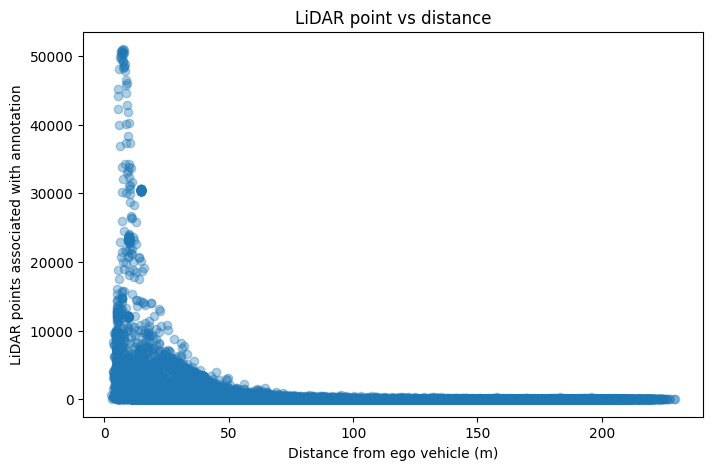

In [15]:
# LiDAR: point count vs distance
plt.figure(figsize=(8, 5))
plt.scatter(
    df['distance_3d'],
    df['num_lidar_pts'],
    alpha=0.35
)
plt.xlabel('Distance from ego vehicle (m)')
plt.ylabel('LiDAR points associated with annotation')
plt.title('LiDAR point vs distance')
plt.show()


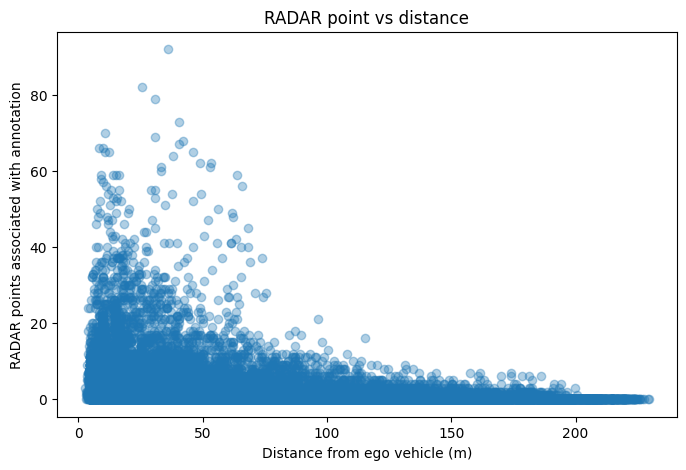

In [16]:
# RADAR: point count vs distance
plt.figure(figsize=(8, 5))
plt.scatter(
    df['distance_3d'],
    df['num_radar_pts'],
    alpha=0.35
)
plt.xlabel('Distance from ego vehicle (m)')
plt.ylabel('RADAR points associated with annotation')
plt.title('RADAR point vs distance')
plt.show()

Initial observation: Both LiDAR and RADAR point evidence decreases as object distance increases. LiDAR provides much denser returns overall, while RADAR remains sparse and shows a declining proportion of annotations with non-zero returns at greater distances. At this stage, the data does not show a clear long-range point-count advantage for RADAR.

In [12]:
bins = [0, 20, 40, 60, 80, 100, np.inf]
labels = ['0-20', '20-40', '40-60', '60-80', '80-100', '100+']
df['distance_bin'] = pd.cut(df['distance_3d'], bins=bins, labels=labels, right=False)

distance_summary = df.groupby('distance_bin', observed=False).agg(
    n_objects=('annotation_token', 'count'),
    median_lidar_pts=('num_lidar_pts', 'median'),
    median_radar_pts=('num_radar_pts', 'median'),
    lidar_return_rate=('num_lidar_pts', lambda x: (x > 0).mean()),
    radar_return_rate=('num_radar_pts', lambda x: (x > 0).mean()),
).reset_index()

distance_summary


,distance_bin,n_objects,median_lidar_pts,median_radar_pts,lidar_return_rate,radar_return_rate
0,0-20,2960,1230.5,3.0,1.0,0.794932
1,20-40,4941,169.0,1.0,1.0,0.647642
2,40-60,4735,55.0,1.0,1.0,0.513411
3,60-80,3542,27.0,0.0,1.0,0.422078
4,80-100,2766,16.0,0.0,1.0,0.363341
5,100+,6806,8.0,0.0,1.0,0.231560


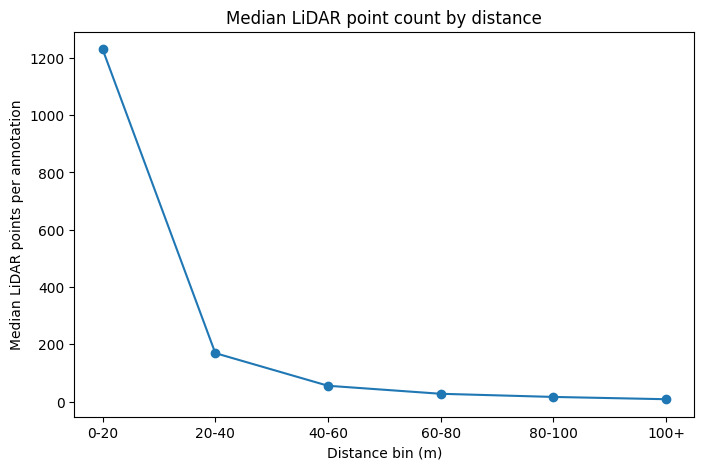

In [20]:
plt.figure(figsize=(8, 5))
plt.plot(
    distance_summary['distance_bin'].astype(str),
    distance_summary['median_lidar_pts'],
    marker='o'
)

plt.xlabel('Distance bin (m)')
plt.ylabel('Median LiDAR points per annotation')
plt.title('Median LiDAR point count by distance')
plt.show()

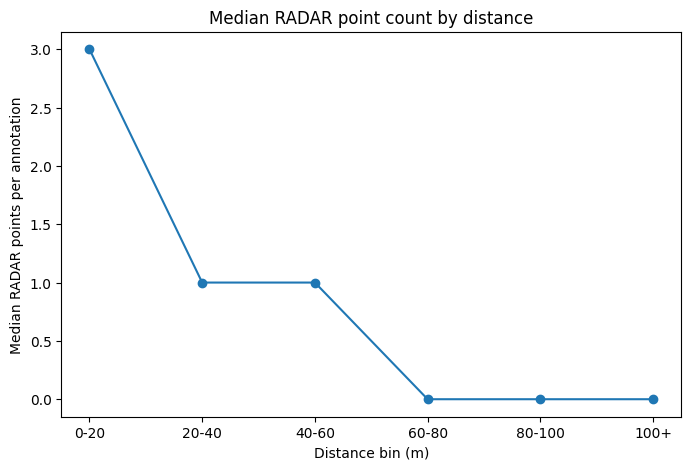

In [21]:
plt.figure(figsize=(8, 5))
plt.plot(
    distance_summary['distance_bin'].astype(str),
    distance_summary['median_radar_pts'],
    marker='o'
)

plt.xlabel('Distance bin (m)')
plt.ylabel('Median RADAR points per annotation')
plt.title('Median RADAR point count by distance')
plt.show()

Initial observation: Between 0–20 m and 20–40 m, the median LiDAR point count decreases more sharply in relative terms than the median RADAR point count. However, RADAR remains much sparser overall, and its median falls to zero beyond 60 m. Therefore, this suggests a possible difference in how point evidence degrades with distance, but not yet a clear long-range advantage for RADAR.

### Distance observations
- TODO: What happens to LiDAR point count as distance increases?
    
    LiDAR point count decreases strongly as distance increases. The median falls from about 1230.5 points at 0–20 m to 169 at 20–40 m, and continues decreasing to only 8 points beyond 100 m.
- TODO: What happens to RADAR point count?
    
    RADAR point count also decreases with distance, but starts from a much lower level. The median falls from 3 points at 0–20 m to 1 point at 20–60 m, then becomes 0 beyond 60 m.
- TODO: Does one sensor's return rate decline more slowly?
    
    For LiDAR, every annotation in the current dataset has at least one associated LiDAR point across all distance bins. RADAR return rate decreases from about 79% at 0–20 m to about 23% beyond 100 m. Therefore, this analysis does not show a clear RADAR advantage in terms of non-zero point returns at longer distances.


# Analysis B: Object size
Questions:
- Do larger annotated objects receive more LiDAR/RADAR points?
- Does object size affect RADAR and LiDAR differently?

`object_volume` is a simple derived size measure from the annotation dimensions. We should also inspect the three dimensions separately if volume hides useful structure.


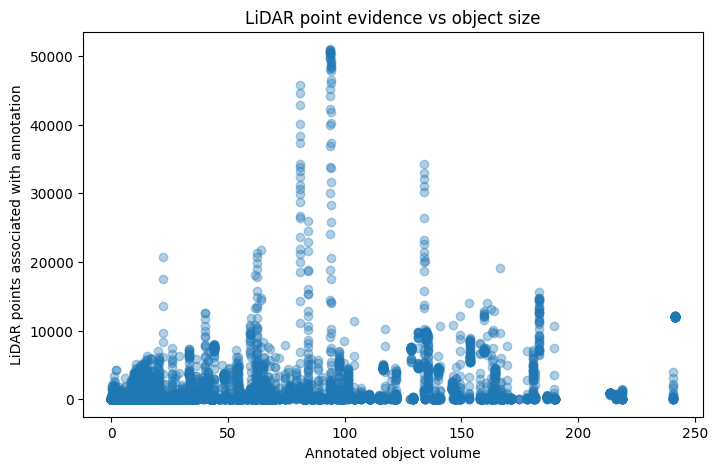

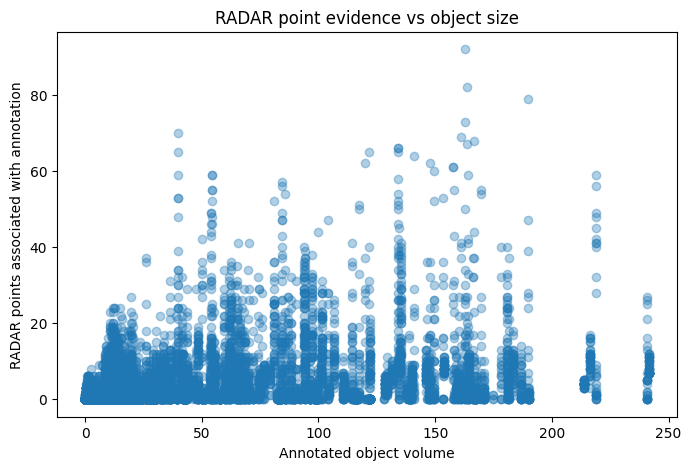

In [22]:
# Optional: remove impossible / zero volumes if needed
plot_df = df[df['object_volume'] > 0].copy()

# Optional: cap very large object volumes so the plot is easier to read
x_cap = plot_df['object_volume'].quantile(0.99)
plot_df_small = plot_df[plot_df['object_volume'] <= x_cap].copy()

# LiDAR plot
plt.figure(figsize=(8, 5))
plt.scatter(plot_df_small['object_volume'], plot_df_small['num_lidar_pts'], alpha=0.35)
plt.xlabel('Annotated object volume')
plt.ylabel('LiDAR points associated with annotation')
plt.title('LiDAR point evidence vs object size')
plt.show()

# RADAR plot
plt.figure(figsize=(8, 5))
plt.scatter(plot_df_small['object_volume'], plot_df_small['num_radar_pts'], alpha=0.35)
plt.xlabel('Annotated object volume')
plt.ylabel('RADAR points associated with annotation')
plt.title('RADAR point evidence vs object size')
plt.show()

Initial observation: There is no clear monotonic relationship between object volume and LiDAR point count. RADAR shows a weak tendency for larger objects to support higher maximum point counts, but the relationship is highly variable and many large objects still receive few or no RADAR returns. Object size alone therefore does not explain sensor return count well.

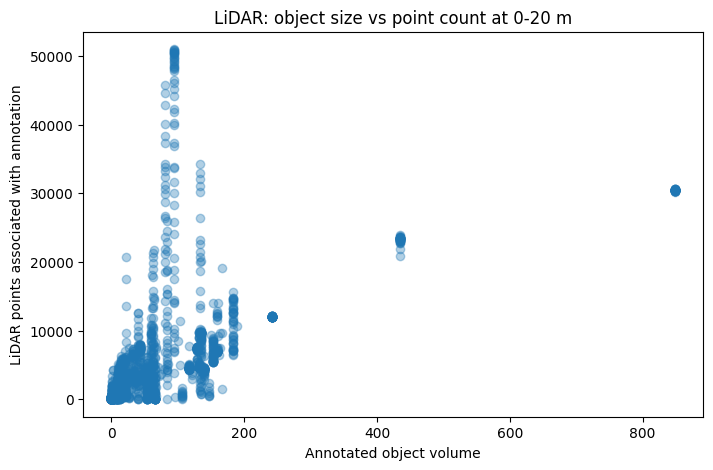

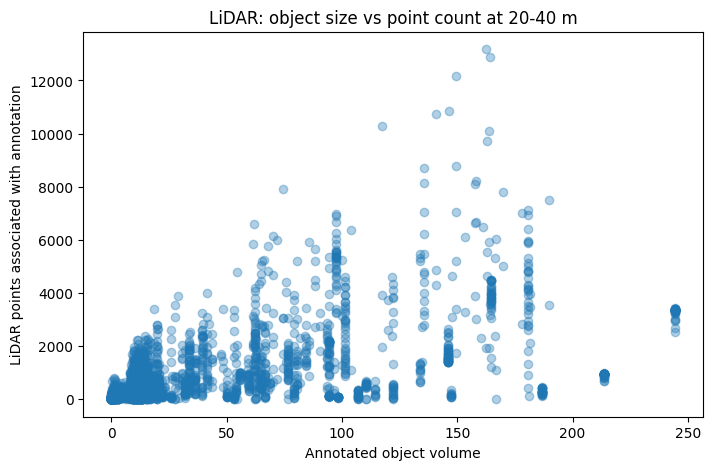

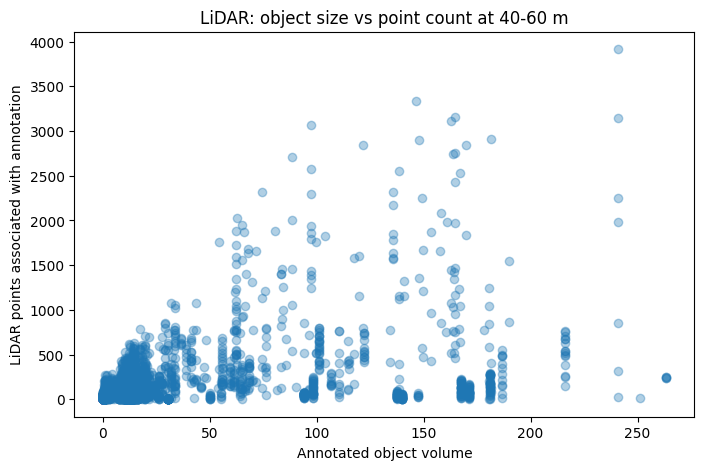

In [23]:
distance_ranges = [
    (0, 20),
    (20, 40),
    (40, 60)
]

for low, high in distance_ranges:
    subset = df[
        (df['distance_3d'] >= low) &
        (df['distance_3d'] < high)
    ]

    plt.figure(figsize=(8, 5))
    plt.scatter(
        subset['object_volume'],
        subset['num_lidar_pts'],
        alpha=0.35
    )

    plt.xlabel('Annotated object volume')
    plt.ylabel('LiDAR points associated with annotation')
    plt.title(f'LiDAR: object size vs point count at {low}-{high} m')
    plt.show()

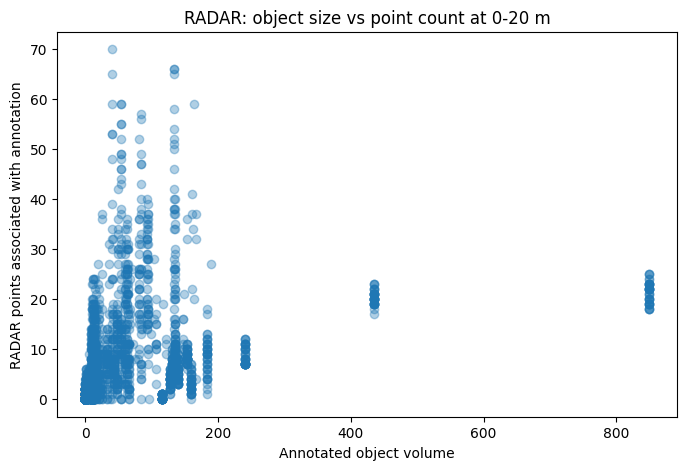

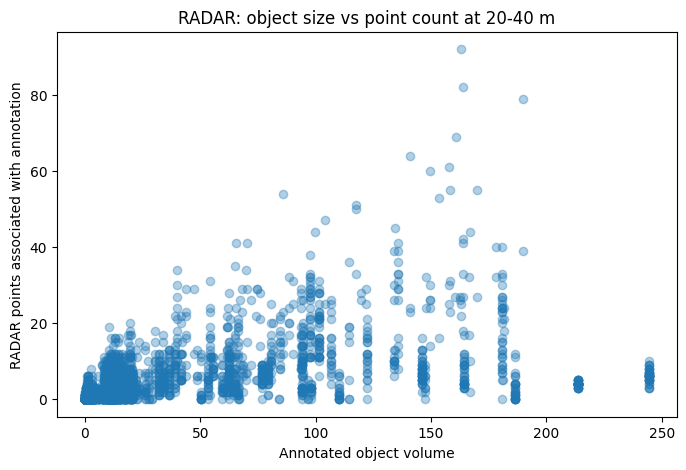

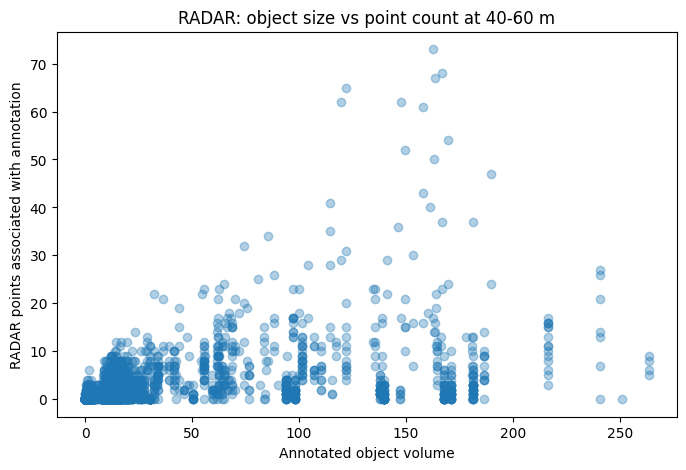

In [24]:
for low, high in distance_ranges:
    subset = df[
        (df['distance_3d'] >= low) &
        (df['distance_3d'] < high)
    ]

    plt.figure(figsize=(8, 5))
    plt.scatter(
        subset['object_volume'],
        subset['num_radar_pts'],
        alpha=0.35
    )

    plt.xlabel('Annotated object volume')
    plt.ylabel('RADAR points associated with annotation')
    plt.title(f'RADAR: object size vs point count at {low}-{high} m')
    plt.show()

Distance-controlled observation: After grouping objects into comparable distance ranges, object size shows a weak-to-moderate positive relationship with sensor point count, particularly in the 20–40 m range. Larger objects are capable of producing higher LiDAR and RADAR point counts, but substantial variability remains. Therefore, object size affects sensor evidence but does not explain it alone.

RADAR-specific observation: Larger objects can produce substantially higher RADAR point counts at similar distances, but some very large objects still produce relatively few RADAR returns. This suggests that physical object volume alone does not determine RADAR response, motivating further investigation of factors such as RCS and object characteristics.

### Object-size observations
- TODO: Is there a clear relationship between size and LiDAR points?
- TODO: Is there a relationship between size and RADAR points?
- TODO: Does distance confound the relationship?
- TODO: Later extension: inspect raw RADAR `rcs` values for points associated with objects.


# Analysis C: Object motion state
Use annotation attributes such as `vehicle.moving`, `vehicle.parked`, `vehicle.stopped`, `pedestrian.moving`, and `pedestrian.standing` where available.

First inspect the attribute distribution.


In [18]:
df['attribute'].value_counts(dropna=False)


attribute
vehicle.moving               10218
traffic_sign.pole_mounted     6297
vehicle.parked                4523
vehicle.stopped               1679
NaN                           1138
pedestrian.moving             1086
traffic_sign.overhanging       262
pedestrian.standing            199
cycle.with_rider               171
traffic_sign.temporary         134
cycle.without_rider             43
Name: count, dtype: int64

In [19]:
motion_summary = df.groupby('attribute', dropna=False).agg(
    n_objects=('annotation_token', 'count'),
    median_lidar_pts=('num_lidar_pts', 'median'),
    median_radar_pts=('num_radar_pts', 'median'),
    lidar_return_rate=('num_lidar_pts', lambda x: (x > 0).mean()),
    radar_return_rate=('num_radar_pts', lambda x: (x > 0).mean()),
).sort_values('n_objects', ascending=False)

motion_summary


,n_objects,median_lidar_pts,median_radar_pts,lidar_return_rate,radar_return_rate
attribute,,,,,
vehicle.moving,10218,34.0,1.0,1.0,0.561754
traffic_sign.pole_mounted,6297,34.0,0.0,1.0,0.227092
vehicle.parked,4523,52.0,1.0,1.0,0.607782
vehicle.stopped,1679,96.0,1.0,1.0,0.668255
NaN,1138,13.0,0.0,1.0,0.246046
pedestrian.moving,1086,42.0,0.0,1.0,0.379374
traffic_sign.overhanging,262,124.0,1.0,1.0,0.511450
pedestrian.standing,199,36.0,0.0,1.0,0.321608
cycle.with_rider,171,58.0,1.0,1.0,0.508772


### Motion-state observations
- TODO: Do moving/stopped/parked objects have different RADAR point patterns?
- TODO: Are apparent differences mainly explained by object type or distance?
- TODO: Next step is to connect raw RADAR velocity measurements to these ground-truth motion-state labels.

> Important: annotation motion state and RADAR relative velocity are not the same concept. Relative velocity depends on both target motion and ego-vehicle motion.


In [25]:
import os
from pypcd4 import PointCloud
from pyquaternion import Quaternion

In [26]:
def load_radar_global(sd_token):
    sd = trucksc.get('sample_data', sd_token)
    cs = trucksc.get('calibrated_sensor', sd['calibrated_sensor_token'])
    ego = trucksc.get('ego_pose', sd['ego_pose_token'])

    path = os.path.join(trucksc.dataroot, sd['filename'])

    pc = PointCloud.from_path(path)

    arr = pc.numpy(
        ('x', 'y', 'z', 'vrel_x', 'vrel_y', 'vrel_z')
    ).astype(float)

    xyz_sensor = arr[:, :3]
    vel = arr[:, 3:6]

    # sensor -> ego
    R_se = Quaternion(cs['rotation']).rotation_matrix
    t_se = np.asarray(cs['translation'])

    xyz_ego = (R_se @ xyz_sensor.T).T + t_se

    # ego -> global
    R_eg = Quaternion(ego['rotation']).rotation_matrix
    t_eg = np.asarray(ego['translation'])

    xyz_global = (R_eg @ xyz_ego.T).T + t_eg

    # For speed magnitude, rotation is unnecessary:
    relative_speed = np.linalg.norm(vel, axis=1)

    return xyz_global, relative_speed

In [27]:
def points_in_annotation(xyz_global, annotation):
    center = np.asarray(annotation['translation'], dtype=float)
    size = np.asarray(annotation['size'], dtype=float)

    R_box = Quaternion(annotation['rotation']).rotation_matrix

    shifted = xyz_global - center
    local = (R_box.T @ shifted.T).T

    # Assuming local x/y/z correspond to the annotation box dimensions.
    half = size / 2

    mask = (
        (np.abs(local[:, 0]) <= half[0]) &
        (np.abs(local[:, 1]) <= half[1]) &
        (np.abs(local[:, 2]) <= half[2])
    )

    return mask

In [28]:
def get_annotation_relative_speed(annotation):
    sample = trucksc.get('sample', annotation['sample_token'])

    speeds = []

    for channel, sd_token in sample['data'].items():

        if not channel.startswith('RADAR'):
            continue

        xyz_global, relative_speed = load_radar_global(sd_token)

        mask = points_in_annotation(
            xyz_global,
            annotation
        )

        speeds.extend(relative_speed[mask])

    if len(speeds) == 0:
        return np.nan

    return np.median(speeds)

In [29]:
vehicle_states = [
    'vehicle.moving',
    'vehicle.parked',
    'vehicle.stopped'
]

vehicle_df = df[df['attribute'].isin(vehicle_states)].copy()

ann_lookup = {
    a['token']: a
    for a in trucksc.sample_annotation
}

vehicle_df['median_relative_speed'] = vehicle_df[
    'annotation_token'
].apply(
    lambda token: get_annotation_relative_speed(
        ann_lookup[token]
    )
)

In [30]:
velocity_summary = vehicle_df.groupby('attribute').agg(
    n_annotations=('annotation_token', 'count'),
    n_with_velocity=('median_relative_speed', 'count'),
    median_relative_speed=('median_relative_speed', 'median'),
    mean_relative_speed=('median_relative_speed', 'mean')
)

velocity_summary

,n_annotations,n_with_velocity,median_relative_speed,mean_relative_speed
attribute,,,,
vehicle.moving,10218,4379,4.928024,10.989476
vehicle.parked,4523,2060,2.673801,3.369865
vehicle.stopped,1679,856,3.492319,3.624591


<Figure size 800x500 with 0 Axes>

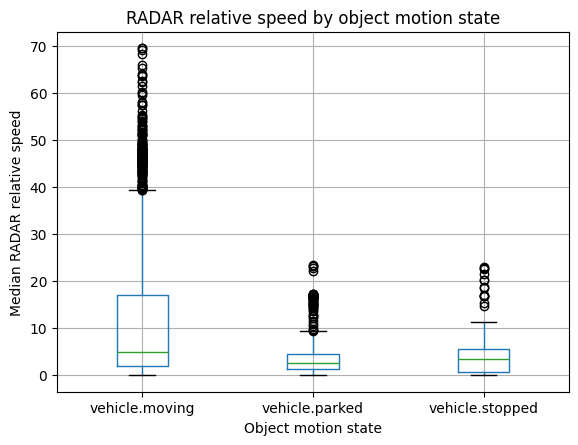

In [31]:
plot_data = vehicle_df.dropna(
    subset=['median_relative_speed']
)

plt.figure(figsize=(8, 5))

plot_data.boxplot(
    column='median_relative_speed',
    by='attribute'
)

plt.xlabel('Object motion state')
plt.ylabel('Median RADAR relative speed')
plt.title('RADAR relative speed by object motion state')
plt.suptitle('')
plt.show()